In [ ]:
# import pandas library for data handling
import pandas as pd

# load the Excel file into a DataFrame called df
df = pd.read_excel('C:\\Users\\user\\Desktop\\Customer Churn Prediction\\data\\raw\\Telco_customer_churn .xlsx')

# print (rows, columns) to see the dataset size
print(df.shape)

# display the first 5 rows to preview the data
df.head()

(7043, 38)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Total services used,Senior citizen (Binary),Tenure group,Average monthly spend,Churn indicator
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,1,86,3239,Competitor made better offer,3,0,0–12 months,54.075000,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,1,67,2701,Moved,1,0,0–12 months,75.825000,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,1,86,5372,Moved,4,0,0–12 months,102.562500,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,1,84,5003,Moved,5,0,25–48 months,108.787500,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,1,89,5340,Competitor had better devices,5,0,49+ months,102.781633,1


In [16]:
# import pandas library for data handling
import pandas as pd

# load the Excel file into a DataFrame called df
df = pd.read_excel('C:\\Users\\user\\Desktop\\Customer Churn Prediction\\data\\raw\\Telco_customer_churn .xlsx')

# print (rows, columns) to see the dataset size
print(df.shape)

df.info()            # show column names, data types, and non-null counts
df.dtypes            # list the data type of each column (int, float, object, etc.)
df.isnull().sum()    # count missing (NaN) values in each column

(7043, 38)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               7043 non-null   str    
 1   Count                    7043 non-null   int64  
 2   Country                  7043 non-null   str    
 3   State                    7043 non-null   str    
 4   City                     7043 non-null   str    
 5   Zip Code                 7043 non-null   int64  
 6   Lat Long                 7043 non-null   str    
 7   Latitude                 7043 non-null   float64
 8   Longitude                7043 non-null   float64
 9   Gender                   7043 non-null   str    
 10  Senior Citizen           7043 non-null   str    
 11  Partner                  7043 non-null   str    
 12  Dependents               7043 non-null   str    
 13  Tenure Months            7043 non-null   int64  
 14  Phone Service           

CustomerID                    0
Count                         0
Country                       0
State                         0
City                          0
Zip Code                      0
Lat Long                      0
Latitude                      0
Longitude                     0
Gender                        0
Senior Citizen                0
Partner                       0
Dependents                    0
Tenure Months                 0
Phone Service                 0
Multiple Lines                0
Internet Service              0
Online Security               0
Online Backup                 0
Device Protection             0
Tech Support                  0
Streaming TV                  0
Streaming Movies              0
Contract                      0
Paperless Billing             0
Payment Method                0
Monthly Charges               0
Total Charges                 0
Churn Label                   0
Churn Value                   0
Churn Score                   0
CLTV    

In [17]:
# generate summary statistics (mean, std, min, max, unique, top) for all columns
df.describe(include='all')         

# count how many times each unique value appears in the target column
df['Churn Label'].value_counts()  

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
print(df.shape)

# remove rows that are exact duplicates of another row
df = df.drop_duplicates()

#drop rows where the target column value is missing (use existing column name)
df = df.dropna(subset=['Churn Label'])

(7043, 38)


In [ ]:
#split into features (X) and target (y), encode categoricals

X = df.drop(columns=['Churn Label'])   # X = feature set, i.e. every column except the target
y = df['Churn Label']                  # y = the target column, i.e. what we want to predict

X = pd.get_dummies(X, drop_first=True)   # convert categorical (text) columns into numeric 0/1 dummy columns

In [ ]:
#train/test split - 80/20 split with fixed random state

from sklearn.model_selection import train_test_split  # import function to split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # split features and target together, keeping row correspondence
    test_size=0.2,          # use 20% of data for testing, 80% for training
    random_state=42          # fix random seed so the split is the same every time it's run
)

In [31]:
# train RandomForest model on training data

from sklearn.ensemble import RandomForestClassifier  # import RandomForest model (use RandomForestRegressor for numeric target)

model = RandomForestClassifier(random_state=42)  # initialize the model with a fixed random seed for reproducibility
model.fit(X_train, y_train)                      # train the model on the training features and labels

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
# generate predictions on test set

y_pred = model.predict(X_test)   # use the trained model to generate predictions on unseen test data

In [32]:
#evaluate model
from sklearn.metrics import accuracy_score, classification_report  # import evaluation metric functions

print(accuracy_score(y_test, y_pred))          # print the fraction of correctly predicted labels
print(classification_report(y_test, y_pred))   # print precision, recall, and f1-score for each class

1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      1009
         Yes       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [33]:
import joblib   # import joblib, a library used to save and load Python objects like trained models

joblib.dump(model, 'model.pkl')   # save the trained model to a file called model.pkl so it can be reused later without retraining

['model.pkl']

In [34]:
import joblib                        # import joblib again to load saved objects

loaded_model = joblib.load('C:\\Users\\user\\Desktop\\Customer Churn Prediction\\notebooks\\model.pkl')   # load the previously saved model back into memory

new_prediction = loaded_model.predict(X_test)   # use the reloaded model to make predictions, just like the original

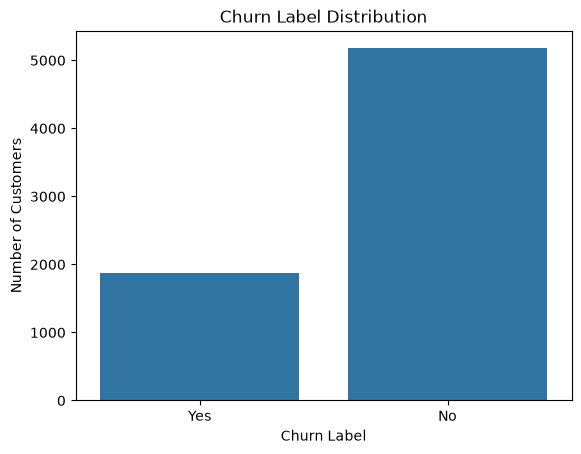

In [42]:
#Target distribution (Churn Label class balance)

import matplotlib.pyplot as plt   # import plotting library
import seaborn as sns             # import seaborn for statistical visualizations

sns.countplot(x='Churn Label', data=df)          # count plot showing how many customers churned vs stayed
plt.title('Churn Label Distribution')            # add chart title
plt.xlabel('Churn Label')                        # label x-axis
plt.ylabel('Number of Customers')                # label y-axis
plt.show()                                        # display the plot

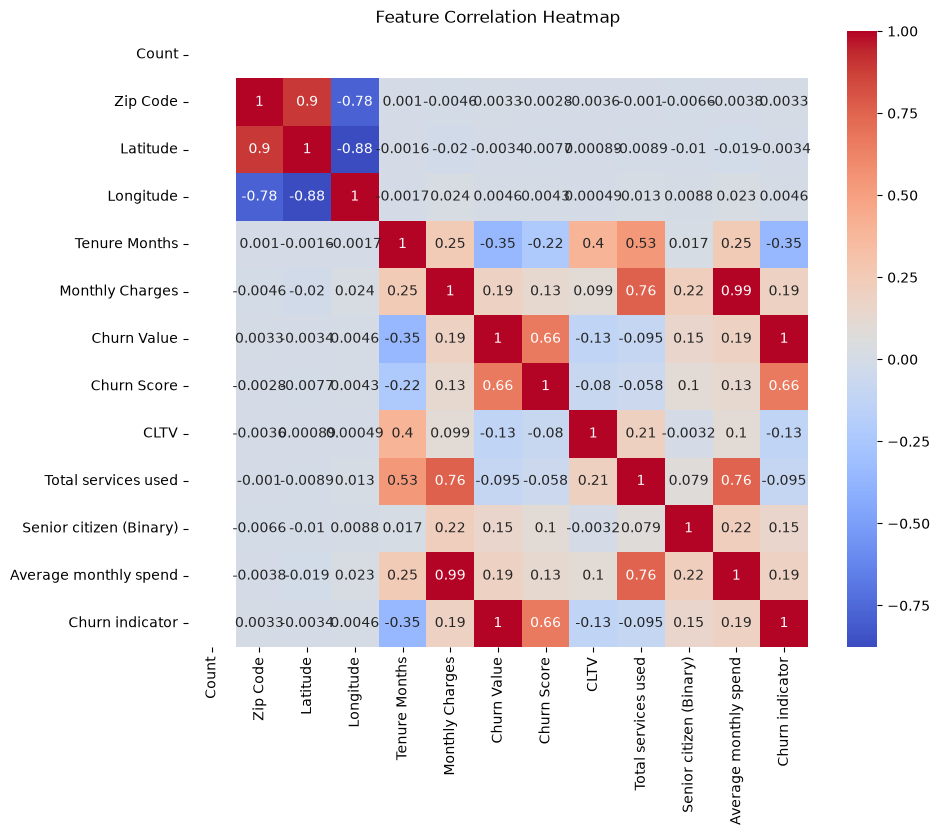

In [43]:
#Correlation heatmap

plt.figure(figsize=(10, 8))                                            # set figure size
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')   # plot correlation matrix for numeric columns
plt.title('Feature Correlation Heatmap')                               # add title
plt.show()                                                              # display the plot                                       # display the plot

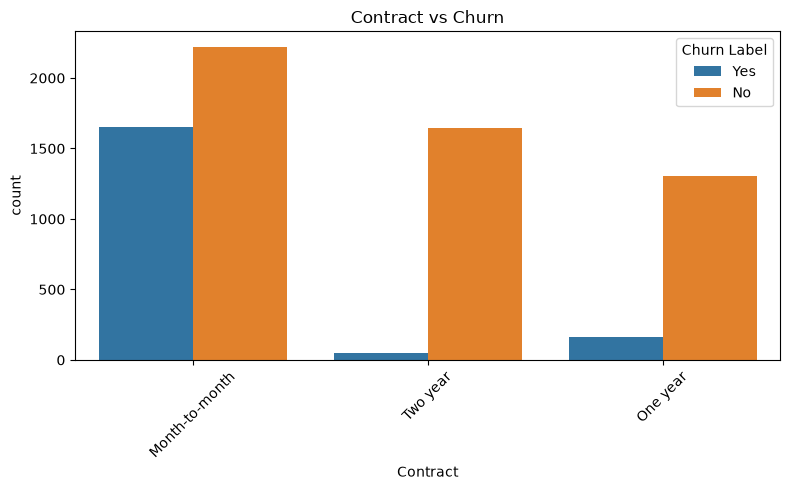

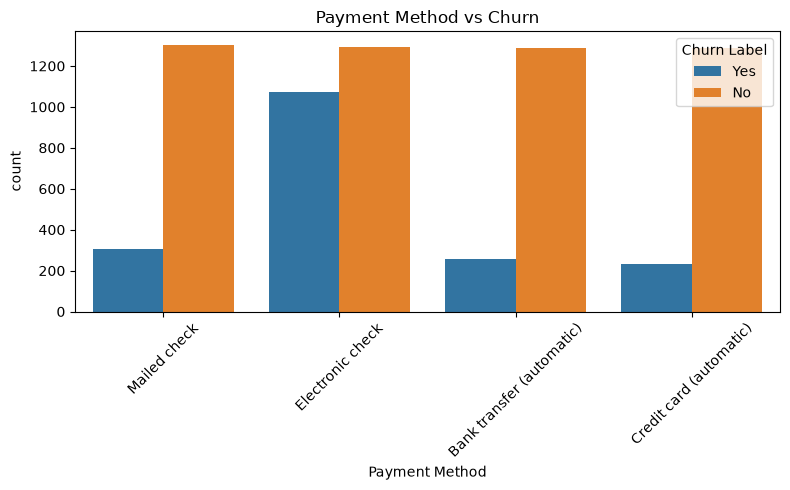

In [45]:
# Categorical features vs Churn

categorical_cols = ['Contract', 'Payment Method']  # use the exact column names from df

for col in categorical_cols:                       # loop through each categorical column
    plt.figure(figsize=(8, 5))                     # set figure size for each plot
    sns.countplot(x=col, hue='Churn Label', data=df)  # grouped bar chart: category counts split by churn
    plt.title(f'{col} vs Churn')                   # dynamic title per column
    plt.xticks(rotation=45)                        # rotate x labels so they don't overlap
    plt.tight_layout()                             # adjust spacing
    plt.show()                                     # display the plot

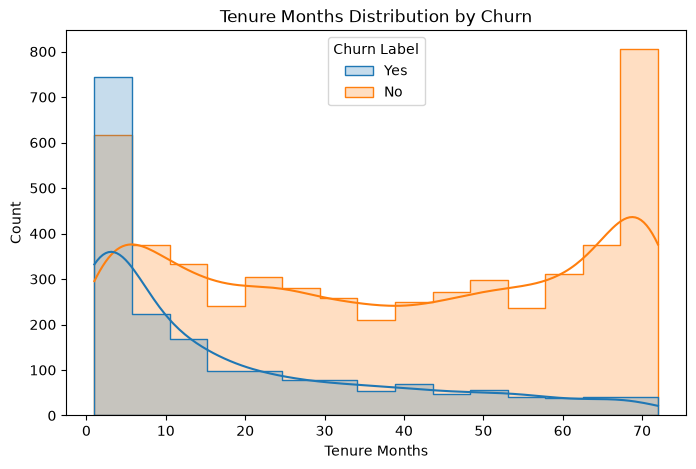

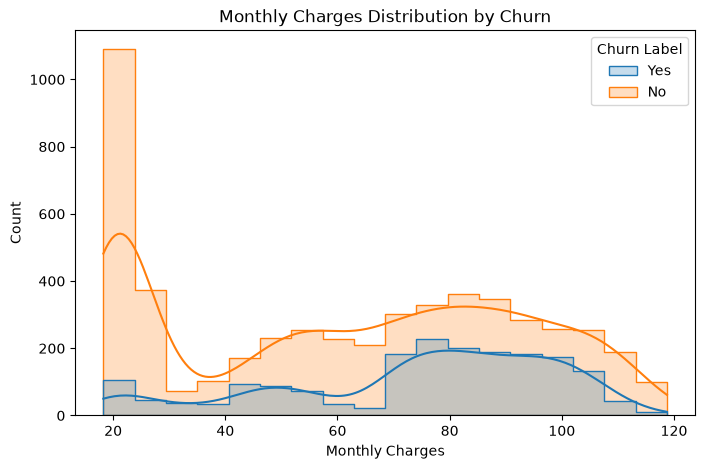

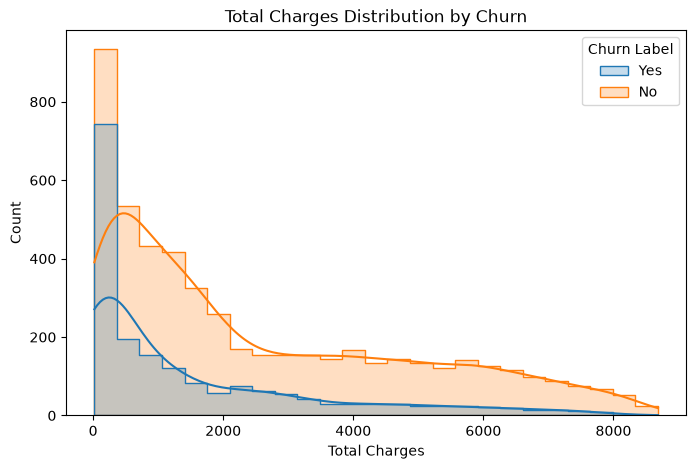

In [48]:
#Numeric distributions with churn overlay

# Clean 'Total Charges' column: convert to numeric, replacing non-numeric values with NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Remove rows with NaN in Total Charges
df_clean = df.dropna(subset=['Total Charges'])

numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']   # numeric columns to examine

for col in numeric_cols:                                                    # loop through each numeric column
    plt.figure(figsize=(8, 5))                                             # set figure size
    sns.histplot(data=df_clean, x=col, hue='Churn Label', kde=True, element='step')  # histogram + KDE, split/colored by churn
    plt.title(f'{col} Distribution by Churn')                              # dynamic title
    plt.show()                                                              # display the plot

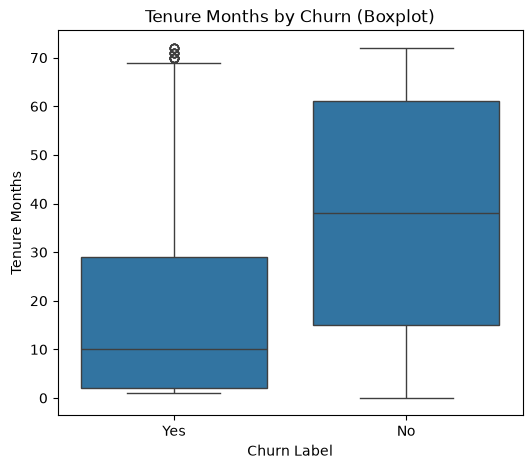

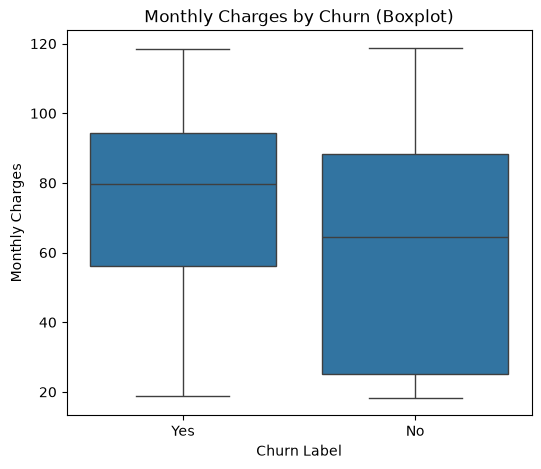

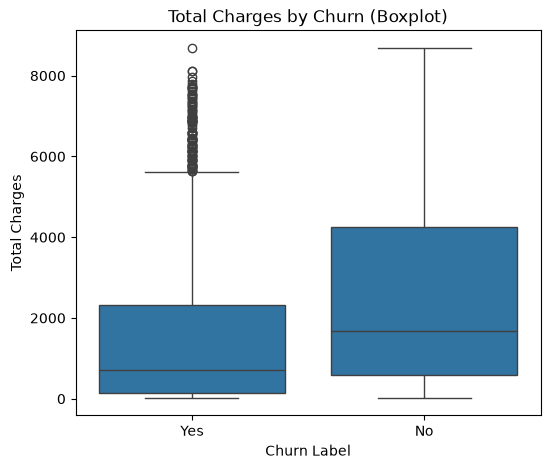

In [49]:
#Boxplots by churn

for col in numeric_cols:                                    # loop through the same numeric columns
    plt.figure(figsize=(6, 5))                              # set figure size
    sns.boxplot(x='Churn Label', y=col, data=df)            # boxplot of the numeric column split by churn status
    plt.title(f'{col} by Churn (Boxplot)')                  # dynamic title
    plt.show()                                               # display the plot

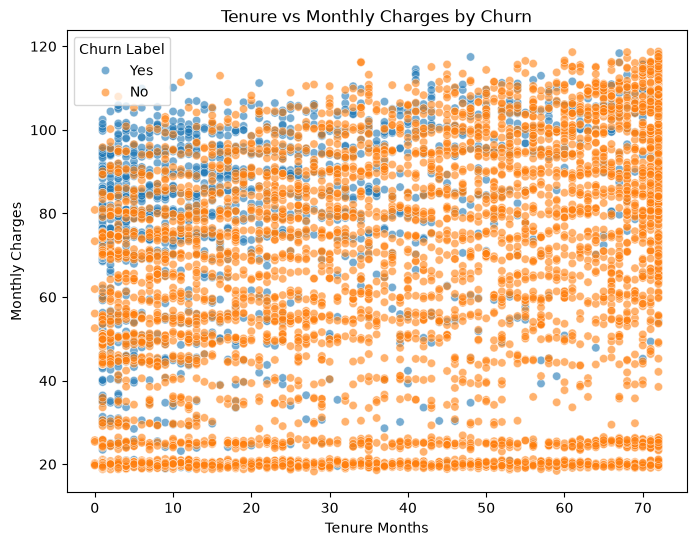

In [51]:
#Tenure vs Charges trend (colored by churn)

plt.figure(figsize=(8, 6))                                                     # set figure size
sns.scatterplot(x='Tenure Months', y='Monthly Charges', hue='Churn Label', data=df, alpha=0.6)  # scatter of tenure vs monthly charges, colored by churn
plt.title('Tenure vs Monthly Charges by Churn')                                # add title
plt.show()                                                                      # display the plot

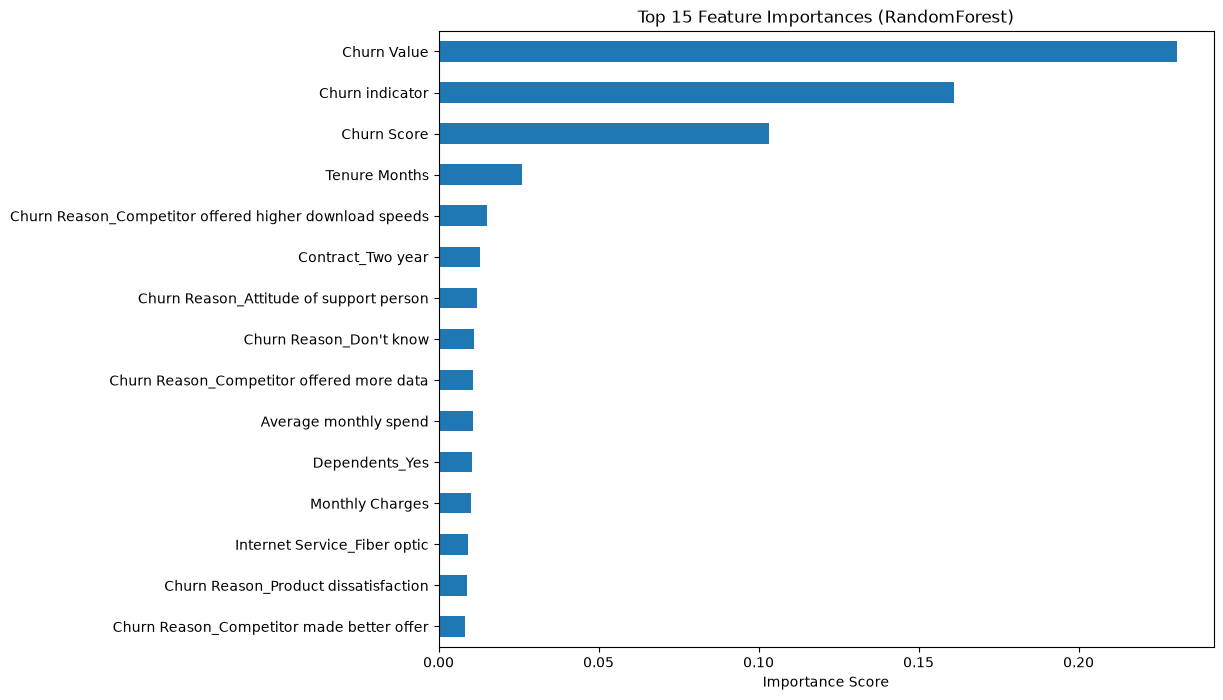

In [52]:
#Feature importance (after one-hot encoding)

importances = model.feature_importances_                     # get importance score for each feature from trained RandomForest
feature_names = X.columns                                     # get corresponding one-hot encoded feature names

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)  # sort by importance descending

plt.figure(figsize=(10, 8))                                    # set figure size
feat_imp.head(15).plot(kind='barh')                            # horizontal bar chart of top 15 most important features
plt.gca().invert_yaxis()                                       # flip so most important feature is at the top
plt.title('Top 15 Feature Importances (RandomForest)')         # add title
plt.xlabel('Importance Score')                                 # label x-axis
plt.show()                                                       # display the plot

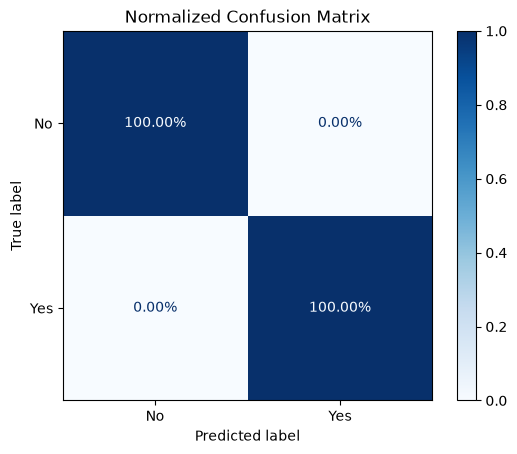

In [53]:
#Confusion matrix (normalized)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # import confusion matrix tools

cm = confusion_matrix(y_test, y_pred, normalize='true')       # compute confusion matrix, normalized by true label (row-wise %)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)  # prepare display with class labels
disp.plot(cmap='Blues', values_format='.2%')                   # plot with percentages formatted to 2 decimal places
plt.title('Normalized Confusion Matrix')                       # add title
plt.show()                                                       # display the plot